# PART A: Build a classification model using text data


### 1. Import the data. The headlines will become your vectorized X matrix, and the labels indicate a binary classification (clickbait or not).

#### Description: The dataset contains news headlines labeled for whether they are clickbait. Each row represents a single headline with two columns: "headline" (the raw text) and "label" (either "clickbait" or "not clickbait"). The dataset is balanced with an equal number of examples in each class. The task is binary classification, predicting whether a given headline is clickbait (1) or not (0).

In [ ]:
# Import Python Libraries
import pandas as pd
import numpy as np
from google.colab import files

# Upload the dataset from my computer
uploaded = files.upload()

# Load the clickbait dataset
data = pd.read_csv("text_training_data.csv")

# Binary encode the label
# The dataset contains news headlines labeled as 'clickbait' or 'not clickbait'.
# I encode the label as a binary integer (1 = clickbait, 0 = not clickbait).
data['label_bin'] = (data['label'] == 'clickbait').astype(int)

print(f"Dataset shape: {data.shape}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print()
data.head(5)

Saving text_training_data.csv to text_training_data (2).csv
Dataset shape: (24979, 3)

Label distribution:
label
not clickbait    12778
clickbait        12201
Name: count, dtype: int64



,headline,label,label_bin
0,MyBook Disk Drive Handles Lots of Easy Backups,not clickbait,0
1,CIT Posts Eighth Loss in a Row,not clickbait,0
2,"Candy Carson Singing The ""National Anthem"" Is ...",clickbait,1
3,Why You Need To Stop What You're Doing And Dat...,clickbait,1
4,27 Times Adele Proved She's Actually The Reale...,clickbait,1


### 2. Convert the headline data into an X feature matrix using a simple bag of words approach.

Note: The train/test split is performed here in Q2 so that the vectorizer is
fit only on training data. This prevents data leakage — if we fit on the full
dataset first, test set vocabulary would bleed into the feature matrix. It also
ensures all three models in Q3 and Q4 are evaluated on the same test set,
making their F1 scores directly comparable.

In [ ]:
# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# We first split into train/test sets (80/20), then apply 'CountVectorizer' with
# default settings to create an X feature matrix from the raw headline text.
# This approach converts each headline into a vector of word counts (unigrams only).

# Define features and target
X = data['headline']
y = data['label_bin']

# Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Model 1 vectorizer: Simple Bag of Words (unigrams, default settings)
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"\nBag-of-Words feature matrix shape (train): {X_train_bow.shape}")
print(f"Vocabulary size: {len(bow_vectorizer.vocabulary_):,} unique tokens")
print(f"\nFirst 15 vocabulary tokens: {list(bow_vectorizer.get_feature_names_out()[:15])}")

Training samples: 19,983
Test samples: 4,996

Bag-of-Words feature matrix shape (train): (19983, 18384)
Vocabulary size: 18,384 unique tokens

First 15 vocabulary tokens: ['000', '00s', '05', '08', '09', '10', '100', '1000', '1000blackgirls', '100m', '100th', '101', '101st', '102', '103']


### 3. Run logistic regression to predict clickbait headlines. Remember to train_test_split your data and use GridSearchCV to find the best value of C. You should evaluate your model with F1 scoring.

In [ ]:
# Import Libraries
# Grid search for C
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# We run logistic regression on the Bag-of-Words matrix, using 'GridSearchCV' with 5-fold CV and **F1 scoring** to find the optimal regularization parameter `C`.

# Model 1: Logistic Regression with Bag of Words
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid1 = GridSearchCV(LogisticRegression(), param_grid, scoring='f1', cv=5)
grid1.fit(X_train_bow, y_train)
print("Best cross-validation score: {:.2f}".format(grid1.best_score_))
print("Best parameters: ", grid1.best_params_)
print(f"Best CV F1 score: {grid1.best_score_:.4f}")

# Evaluate on test set
y_pred1 = grid1.predict(X_test_bow)
f1_1 = f1_score(y_test, y_pred1)
print(f"Test Set F1 Score: {f1_1:.4f}")

Best cross-validation score: 0.97
Best parameters:  {'C': 10}
Best CV F1 score: 0.9688
Test Set F1 Score: 0.9662


### 4. Run 2 more logistic regression models by changing the vectorization approach (e.g. using n-grams, stop_words, and other techniques we discussed). In both cases, keep your logistic regression step the same (which includes finding the optimal value of C each time). Only change how you're generating the X matrix from the text data.

In [ ]:
# Import Libraries
from sklearn.feature_extraction.text import TfidfVectorizer

# Model 2: TF-IDF, stop words removed, min_df=3
tfidf_vectorizer = TfidfVectorizer(stop_words='english', min_df=3)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature matrix shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,} tokens (stop words and rare tokens removed)")

grid2 = GridSearchCV(LogisticRegression(), param_grid, scoring='f1', cv=5)
grid2.fit(X_train_tfidf, y_train)

print(f"\nBest C (Model 2): {grid2.best_params_['C']}")
print(f"Best CV F1 score: {grid2.best_score_:.4f}")

y_pred2 = grid2.predict(X_test_tfidf)
f1_2 = f1_score(y_test, y_pred2)
print(f"Test Set F1 Score: {f1_2:.4f}")

TF-IDF feature matrix shape (train): (19983, 6888)
Vocabulary size: 6,888 tokens (stop words and rare tokens removed)

Best C (Model 2): 10
Best CV F1 score: 0.9498
Test Set F1 Score: 0.9485


In [ ]:
# Model 3: TF-IDF, unigrams and bigrams, stop words removed, min_df=5
bigram_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english',
    min_df=5)
X_train_bigram = bigram_vectorizer.fit_transform(X_train)
X_test_bigram  = bigram_vectorizer.transform(X_test)

print(f"\nBigram TF-IDF feature matrix shape (train): {X_train_bigram.shape}")
print(f"Vocabulary size: {len(bigram_vectorizer.vocabulary_):,} unigrams + bigrams")

grid3 = GridSearchCV(LogisticRegression(), param_grid, scoring='f1', cv=5)
grid3.fit(X_train_bigram, y_train)

print(f"\nBest C (Model 3): {grid3.best_params_['C']}")
print(f"Best CV F1 score: {grid3.best_score_:.4f}")

y_pred3 = grid3.predict(X_test_bigram)
f1_3    = f1_score(y_test, y_pred3)
print(f"Test Set F1 Score: {f1_3:.4f}")


Bigram TF-IDF feature matrix shape (train): (19983, 5575)
Vocabulary size: 5,575 unigrams + bigrams

Best C (Model 3): 10
Best CV F1 score: 0.9478
Test Set F1 Score: 0.9450


### 5. Which of your 3 models performed best? What are the most significant coefficients in each, and how do they compare?

In [ ]:
# Helper function to plot top positive and negative coefficients
def visualize_coefficients(coefficients, feature_names, n_top_features=25):
    coefficients = coefficients.squeeze()
    if coefficients.ndim > 1:
        raise ValueError("coefficients must be 1d array or column vector, got"
                         " shape {}".format(coefficients.shape))
    coefficients = coefficients.ravel()
    if len(coefficients) != len(feature_names):
        raise ValueError("Number of coefficients {} doesn't match number of"
                         "feature names {}.".format(len(coefficients),
                                                    len(feature_names)))
    coef = coefficients.ravel()
    positive_coefficients = np.argsort(coef)[-n_top_features:]
    negative_coefficients = np.argsort(coef)[:n_top_features]
    interesting_coefficients = np.hstack([negative_coefficients,
                                          positive_coefficients])
    plt.figure(figsize=(15, 5))
    colors = ['#ff2020' if c < 0 else '#0000aa'
              for c in coef[interesting_coefficients]]
    plt.bar(np.arange(2 * n_top_features), coef[interesting_coefficients],
            color=colors)
    feature_names = np.array(feature_names)
    plt.subplots_adjust(bottom=0.3)
    plt.xticks(np.arange(1, 1 + 2 * n_top_features),
               feature_names[interesting_coefficients], rotation=60,
               ha="right")
    plt.ylabel("Coefficient magnitude")
    plt.xlabel("Feature")

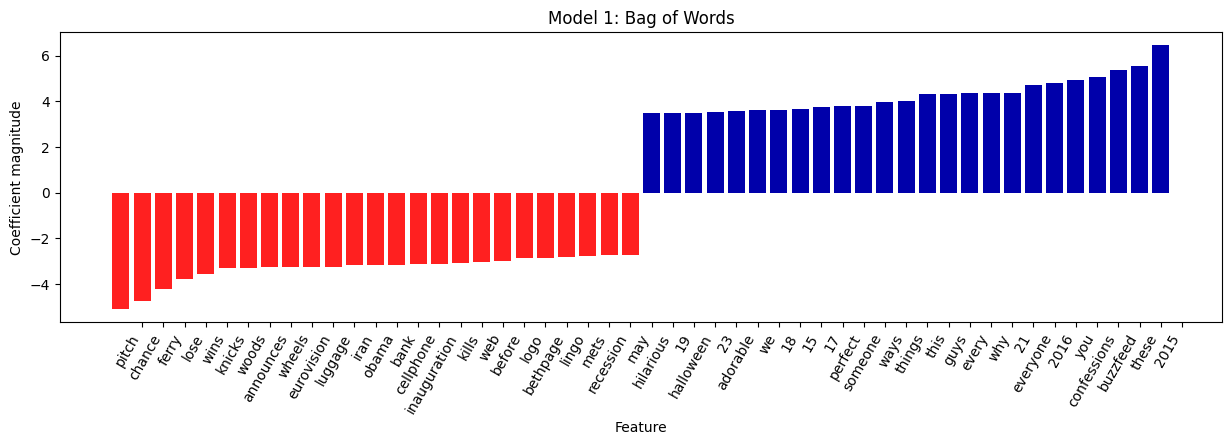

In [ ]:
# Import Libraries
import matplotlib.pyplot as plt

# Model 1: Bag of Words
coefs1 = grid1.best_estimator_.coef_
feature_names1 = bow_vectorizer.get_feature_names_out()
visualize_coefficients(coefs1, feature_names1, n_top_features=25)
plt.title("Model 1: Bag of Words")
plt.show()

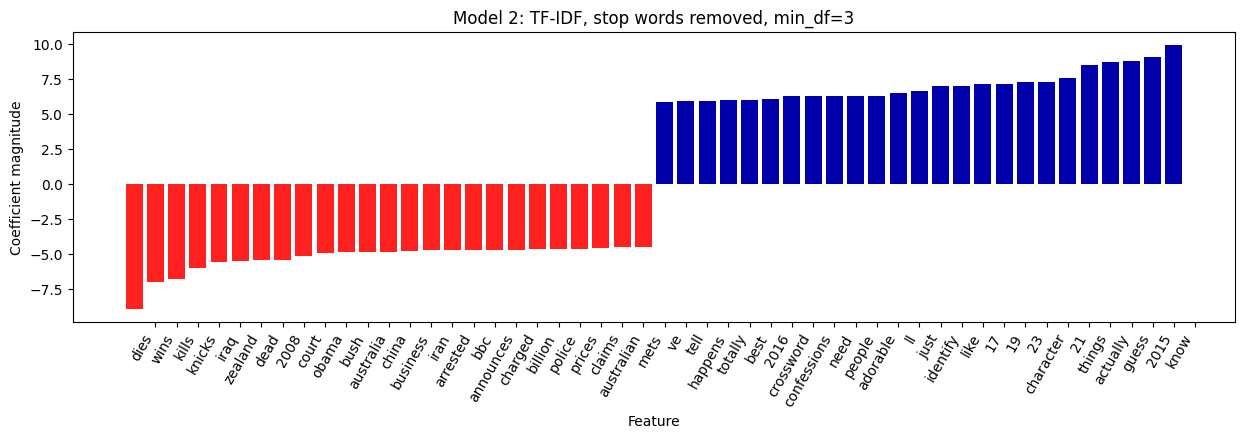

In [ ]:
# Model 2: TF-IDF, stop words removed
coefs2 = grid2.best_estimator_.coef_
feature_names2 = tfidf_vectorizer.get_feature_names_out()
visualize_coefficients(coefs2, feature_names2, n_top_features=25)
plt.title("Model 2: TF-IDF, stop words removed, min_df=3")
plt.show()

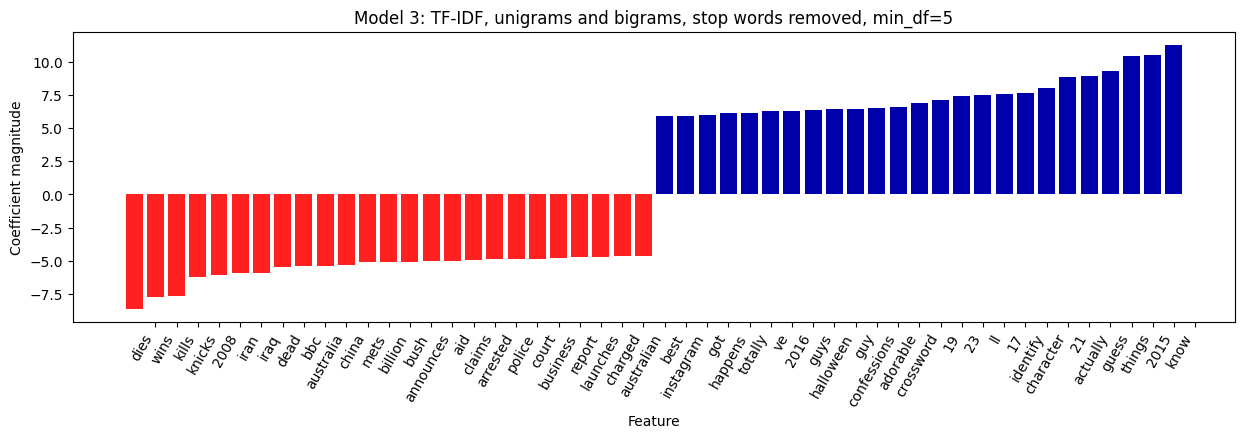

In [ ]:
# Model 3: TF-IDF, unigrams and bigrams, stop words removed
coefs3 = grid3.best_estimator_.coef_
feature_names3 = bigram_vectorizer.get_feature_names_out()
visualize_coefficients(coefs3, feature_names3, n_top_features=25)
plt.title("Model 3: TF-IDF, unigrams and bigrams, stop words removed, min_df=5")
plt.show()

In [ ]:
# Summary table
summary = pd.DataFrame({
    'Model': ['Model 1: BoW', 'Model 2: TF-IDF, stop words removed', 'Model 3: TF-IDF, unigrams and bigrams, stop words removed'],
    'Best C': [grid1.best_params_['C'], grid2.best_params_['C'], grid3.best_params_['C']],
    'CV F1': [grid1.best_score_, grid2.best_score_, grid3.best_score_],
    'Test F1': [f1_1, f1_2, f1_3]
})
print(summary.round(4))

                                               Model  Best C   CV F1  Test F1
0                                       Model 1: BoW      10  0.9688   0.9662
1                Model 2: TF-IDF, stop words removed      10  0.9498   0.9485
2  Model 3: TF-IDF, unigrams and bigrams, stop wo...      10  0.9478   0.9450


**Which model performed best?**

Model 1 (Bag of Words) performed best, achieving the highest CV F1 score (0.9688) and Test F1 score (0.9662). Model 2 (TF-IDF, stop words removed) and Model 3 (TF-IDF, unigrams and bigrams, stop words removed) performed slightly worse, scoring 0.9498 and 0.9478 on CV F1 respectively.

This is somewhat counterintuitive, but makes sense in context: clickbait headlines rely heavily on repeated, recognizable vocabulary, such as list-number words like "21" or "27", and engagement words like "know". Raw word counts capture the repetitive, formulaic nature of clickbait better than TF-IDF, which down-weights frequently occurring words, which is exactly the signal we want to preserve. All three models selected C = 10 as optimal, indicating moderate regularization works best across all vectorization strategies. The differences are small, suggesting that for this dataset simple word counts are already highly effective and the additional complexity of TF-IDF reweighting and bigrams does not provide a meaningful improvement.

**Most significant coefficients:**

Across all three models, the most significant coefficients are consistent in
direction and largely similar in content.

**Model 1 (Bag of Words):** The strongest clickbait indicators (blue, positive coefficients) are *2015, these, buzzfeed, confessions, 2016, everyone, 21* — list-number words, year references typical of viral content. BuzzFeed also appears as a top feature in Model 1, which makes sense as a well-known clickbait publisher. The strongest non-clickbait indicators are *pitch, chance, ferry, lose, wins*, specific factual words associated with sports and news reporting.

**Model 2 (TF-IDF, stop words removed):** The strongest clickbait indicators are *know, 2015, guess, actually, things, 21, character, adorable, confessions*, vague engagement words and list-number words. The strongest non-clickbait indicators are *dies, wins, kills, knicks, iraq, zealand, dead, 2008, court*, proper nouns/countries and event-specific language typical of hard news.

**Model 3 (TF-IDF + Bigrams + stop words removed):** The strongest clickbait indicators are *know, 2015, things, guess, actually, 21, character, identify, adorable, confessions* — very similar to Model 2, with no bigrams appearing among the top features. The strongest non-clickbait indicators are *dies, wins, kills, knicks, 2008, iran, iraq, dead* — again consistent with Models 2.

**How do they compare across models?**
All three models agree on the direction of the most significant features.
Numbers like *21* and year references like *2015* are consistently the
strongest clickbait signals across all models, reflecting the list-number and years format common in clickbait. Words like *dies, wins, kills* are the strongest non-clickbait signals across Model 2 and 3, reflecting factual sports and news language, likely because TF-IDF upweights these specific terms more than plain word counts do.

Model 3's bigrams did not reveal strongly distinctive two-word phrase features at the top level, suggesting that for short headline text, unigrams already capture most discriminating signal, and adding bigrams slightly increases noise without proportional benefit.

The main difference between models is in coefficient magnitude — Models 2
and 3 show much larger coefficients (up to ~10) compared to Model 1 (up to
~6.5), because TF-IDF reweighting amplifies the most discriminative terms.

# Part B: Build a Predictive Neural Network Using Keras

### 1. Load the data. Data can be imported directly using pd.read_csv() and the link http://vincentarelbundock.github.io/Rdatasets/csv/datasets/iris.csv.


#### Description: The iris dataset contains 150 flower samples across 3 species: setosa, versicolor, and virginica (50 samples each). Each sample has 4 numerical features: sepal length, sepal width, petal length, and petal width,all measured in centimeters. The task is multiclass classification, predicting the flower species from its measurements.

In [ ]:
# Import Python Libraries
import pandas as pd
import numpy as np

# Load the iris dataset
data2 = pd.read_csv("http://vincentarelbundock.github.io/Rdatasets/csv/datasets/iris.csv")
print(f"Dataset shape: {data2.shape}")
print(f"\nClass distribution:\n{data2['Species'].value_counts()}")
data2.head(10)



Dataset shape: (150, 6)

Class distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,rownames,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa
5,6,5.4,3.9,1.7,0.4,setosa
6,7,4.6,3.4,1.4,0.3,setosa
7,8,5.0,3.4,1.5,0.2,setosa
8,9,4.4,2.9,1.4,0.2,setosa
9,10,4.9,3.1,1.5,0.1,setosa


### 2. Using the Sequential interface in Keras, build a model with 2 hidden layers with 16 neurons in each. Compile and fit the model. Assess its performance using ROC AUC on data that has been train_test_split.

In [ ]:
# Import Libraries
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import SGD

# Perform one-hot encoding for labels
# Multiclass classification: softmax output with 1 neuron per class
data = pd.get_dummies(data2, columns=['Species'])

X = data[["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]]
labels = data[["Species_setosa", "Species_versicolor", "Species_virginica"]]

display(labels)

,Species_setosa,Species_versicolor,Species_virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, labels, random_state=42)
print("X_train.shape: {}".format(X_train.shape))

# Build a fully connected neural network
# 2 hidden layers with 16 neurons in each
# Activation set to relu
# 1 output layer with 3 categories (one per species)

model1 = Sequential([
    Dense(16, input_shape=(4,)),
    Activation('relu'),
    Dense(16),
    Activation('relu'),
    Dense(3),
    Activation('softmax'),
])

# Examine the model structure
model1.summary()

X_train.shape: (112, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model1.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['auc'])

# Train the model, iterating on the data in batches of 32 samples
model1.fit(X_train, y_train, validation_split=0.20, epochs=50, batch_size=32, verbose=0)

# Evaluate performance on the test set
score = model1.evaluate(X_test, y_test, batch_size=128)

print(f'\nTest Set Loss: {score[0]}')
print(f'Test Set AUC: {score[1]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - auc: 0.9952 - loss: 0.3580

Test Set Loss: 0.3579532206058502
Test Set AUC: 0.9951523542404175


### 3. Run 2 additional models using different numbers of hidden layers and/or hidden neurons.


In [ ]:
# Build model 2 with 2 hidden layers, 16 neurons in hidden layer 1 and 32 neurons in hidden layer 2
model2 = Sequential([
    Dense(16, input_shape=(4,)),
    Activation('relu'),
    Dense(32),
    Activation('relu'),
    Dense(3),
    Activation('softmax'),
])

# Examine the model structure
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 723 (2.82 KB)

 Trainable params: 723 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['auc'])

model2.fit(X_train, y_train, validation_split=0.20, epochs=50, batch_size=32, verbose=0)

score = model2.evaluate(X_test, y_test, batch_size=128)

print(f'\nTest Set Loss: {score[0]}')
print(f'Test Set AUC: {score[1]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - auc: 1.0000 - loss: 0.3901

Test Set Loss: 0.3901105523109436
Test Set AUC: 1.0


In [ ]:
# Build model 3 with 3 hidden layers, 16 neurons in hidden layer 1,
# 16 neurons in hidden layer 2, 32 neurons in hidden layer 3
model3 = Sequential([
    Dense(16, input_shape=(4,)),
    Activation('relu'),
    Dense(16),
    Activation('relu'),
    Dense(32),
    Activation('relu'),
    Dense(3),
    Activation('softmax'),
])

# Examine the model structure
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995 (3.89 KB)

 Trainable params: 995 (3.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['auc'])

model3.fit(X_train, y_train, validation_split=0.20, epochs=50, batch_size=32, verbose=0)

score = model3.evaluate(X_test, y_test, batch_size=128)

print(f'\nTest Set Loss: {score[0]}')
print(f'Test Set AUC: {score[1]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - auc: 0.9919 - loss: 0.3861

Test Set Loss: 0.3860548734664917
Test Set AUC: 0.9918628931045532


### 4. How does the performance compare between your 3 models?

In [ ]:
# Evaluate all three models and collect AUC scores
score1 = model1.evaluate(X_test, y_test, batch_size=128, verbose=0)
score2 = model2.evaluate(X_test, y_test, batch_size=128, verbose=0)
score3 = model3.evaluate(X_test, y_test, batch_size=128, verbose=0)

# Summary table
summary = pd.DataFrame({
    'Model': [
        'Model 1: 2 layers (16, 16)',
        'Model 2: 2 layers (16, 32)',
        'Model 3: 3 layers (16, 16, 32)'
    ],
    'Hidden Layers': [2, 2, 3],
    'Neurons per Layer': ['16, 16', '16, 32', '16, 16, 32'],
    'Test Loss': [score1[0], score2[0], score3[0]],
    'Test AUC': [score1[1], score2[1], score3[1]]
})
print(summary.round(4))

                            Model  Hidden Layers Neurons per Layer  Test Loss  \
0      Model 1: 2 layers (16, 16)              2            16, 16     0.3580   
1      Model 2: 2 layers (16, 32)              2            16, 32     0.3901   
2  Model 3: 3 layers (16, 16, 32)              3        16, 16, 32     0.3861   

   Test AUC  
0    0.9952  
1    1.0000  
2    0.9919  


All three models achieve high ROC AUC scores (above 0.99), which is expected
given that the iris dataset is small, clean, and well-separated.

Model 2 (2 hidden layers, 16 and 32 neurons) achieved the highest AUC of
1.0000, perfectly classifying all test samples. Model 1 (2 hidden layers, 16
neurons each) performed second best with an AUC of 0.9952 and the lowest test
loss of 0.3580, suggesting its predictions are better calibrated despite a
slightly lower AUC than Model 2. Model 3 (3 hidden layers) achieved the lowest
AUC of 0.9919 and a test loss of 0.3861, indicating that adding a third hidden
layer did not improve performance on this dataset.

Overall, the differences between models are very small and unlikely to be
meaningful in practice. On a simple 4-feature, 3-class problem like iris, all
three architectures are more than sufficient, and performance is largely
determined by random weight initialisation rather than architectural differences.